# Sensitivity of fitted κ_m to σ_ITD / σ_ILD perturbations

**Goal:** Address reviewer comment that fixing σ_ITD and σ_ILD may conflate individual differences in
ITD/ILD sensitivity with motor noise.

**Approach:**
1. Re-run Stage 1 (motor noise estimation) for all participants across a 3×3 grid of
   (σ_ITD, σ_ILD) values bracketing the known inter-individual JND ranges.
2. Show fitted κ_m is virtually unchanged across conditions (Panel A).
3. Show the spread of rmsL predicted by σ_ITD/σ_ILD variation alone (κ_m=∞) is
   negligible compared to the observed inter-individual range (Panel B).

**Physiological basis for grid:**
- σ_ITD: default 0.569; ±25% brackets the ~20–30 µs JND range (Mossop & Culling 1998)
- σ_ILD: default 1.0 dB; ±0.5 dB brackets ~1 dB inter-individual spread (Yost 1988)

The numbers quoted in Sec. 3.4 (r > 0.998, mean |Δσ_m| 0.30°, max 2.05°; no-motor rmsL 2.7° ± 1.4°,
envelope ≤ 1.94°, mean 0.51°; observed range 3.0°–34.7°) are in the saved outputs below, computed
with a development version of `bayesian_listener` preceding 0.2.0. Needs the participant HRTFs
(`data/hrtf/`) and the behavioural data (`data/behavioural/`).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.special import i0, i1
from scipy.optimize import minimize_scalar
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import pyfar as pf

from bayesian_listener import BayesianListener

import paths

def wrap_to_pi(rad):
    return (rad + np.pi) % (2 * np.pi) - np.pi

def rmsL(targ_lat, est_lat, cutoff_deg=30):
    """RMS lateral error for targets within ±cutoff_deg (inputs in radians)."""
    mask = np.abs(targ_lat) <= np.deg2rad(cutoff_deg)
    if not np.any(mask):
        return np.nan
    diff = wrap_to_pi(est_lat[mask] - targ_lat[mask])
    return np.sqrt(np.mean(diff**2))

def von_mises_loglik_mc(kappa, resp_lat, est_lat_mc):
    log_C = -np.log(2 * np.pi * i0(kappa))
    lat_diff = resp_lat[:, None] - est_lat_mc
    log_pdfs = log_C + kappa * np.cos(lat_diff)
    max_log = np.max(log_pdfs, axis=1, keepdims=True)
    log_mean = max_log[:, 0] + np.log(np.mean(np.exp(log_pdfs - max_log), axis=1))
    return -np.sum(log_mean)

def fit_kappa_ml(resp_lat, est_lat_mc):
    result = minimize_scalar(von_mises_loglik_mc, bounds=(0.1, 1000),
                             args=(resp_lat, est_lat_mc), method='bounded')
    return result.x

def kappa_to_sigma(kappa):
    if kappa < 1e-6:
        return 180.0
    R = i1(kappa) / i0(kappa)
    return np.rad2deg(np.sqrt(-2 * np.log(R)))

# Behavioural data (target directions and responses)
dirs = pd.read_csv(paths.DIRS_FILE)

targets_coords = pf.Coordinates.from_spherical_elevation(
    np.deg2rad(dirs['azi_target'].values),
    np.deg2rad(dirs['ele_target'].values),
    np.ones(len(dirs)))

obs_tbl = pd.read_csv(paths.BEHAV_FILE)
obs_tbl = obs_tbl[(obs_tbl['condition'] == 'Measured') & (obs_tbl['participant'] != 'P0247')]
participants = obs_tbl['participant'].unique()
print(f'Participants: {len(participants)}')

Participants: 33


## Define σ_ITD / σ_ILD grid

In [2]:
SIGMA_ITD_DEFAULT = 0.569
SIGMA_ILD_DEFAULT = 1.0

sigma_itd_grid = np.array([SIGMA_ITD_DEFAULT * 0.5,
                            SIGMA_ITD_DEFAULT,
                            SIGMA_ITD_DEFAULT * 1.50])
sigma_ild_grid = np.array([0.75, 1.0, 1.25])

conditions = [(sit, sil) for sit in sigma_itd_grid for sil in sigma_ild_grid]
default_idx = conditions.index((SIGMA_ITD_DEFAULT, SIGMA_ILD_DEFAULT))

print(f'σ_ITD values: {sigma_itd_grid}')
print(f'σ_ILD values: {sigma_ild_grid}')
print(f'Total conditions: {len(conditions)} (default is condition #{default_idx})')

σ_ITD values: [0.2845 0.569  0.8535]
σ_ILD values: [0.75 1.   1.25]
Total conditions: 9 (default is condition #4)


## Fit κ_m for all participants × all conditions

In [3]:
N_MC = 100
np.random.seed(42)

kappa_results = {pid: {} for pid in participants}

for pid in participants:
    subj_data = obs_tbl[obs_tbl['participant'] == pid]
    sofa_path = str(paths.participant_sofa(pid))

    model = BayesianListener(sofa_path)
    model.compute_template(interpolation='SHMAX', cache_dir=paths.CACHE_DIR)

    template_itd = model.template.itd.flatten()
    template_ild = model.template.ild.flatten()
    template_lat = model.template.coords.lateral

    target_indices = model.coords.find_nearest(targets_coords)[0][0]
    target_itd = model.target.itd[target_indices].flatten()
    target_ild = model.target.ild[target_indices].flatten()

    resp_coords = pf.Coordinates.from_spherical_elevation(
        np.deg2rad(subj_data['azi_response'].values),
        np.deg2rad(subj_data['ele_response'].values),
        np.ones(len(subj_data)))
    resp_lat = resp_coords.lateral

    targ_coords = pf.Coordinates.from_spherical_elevation(
        np.deg2rad(subj_data['azi_target'].values),
        np.deg2rad(subj_data['ele_target'].values),
        np.ones(len(subj_data)))
    targ_lat = targ_coords.lateral
    trial_target_indices = targets_coords.find_nearest(targ_coords)[0][0]

    mask = np.abs(targ_lat) <= np.deg2rad(30)
    resp_lat_filt = resp_lat[mask]
    trial_idx_filt = trial_target_indices[mask]

    for c_idx, (sigma_itd, sigma_ild) in enumerate(conditions):
        est_lat_mc = np.zeros((np.sum(mask), N_MC))

        for i, t_idx in enumerate(trial_idx_filt):
            noisy_itd = target_itd[t_idx] + np.random.normal(0, sigma_itd, N_MC)
            noisy_ild = target_ild[t_idx] + np.random.normal(0, sigma_ild, N_MC)

            itd_diff = (template_itd[None, :] - noisy_itd[:, None]) / sigma_itd
            ild_diff = (template_ild[None, :] - noisy_ild[:, None]) / sigma_ild
            loglik = -0.5 * (itd_diff**2 + ild_diff**2)

            best_indices = np.argmax(loglik, axis=1)
            est_lat_mc[i, :] = template_lat[best_indices]

        kappa_results[pid][c_idx] = fit_kappa_ml(resp_lat_filt, est_lat_mc)

    sigma_m = kappa_to_sigma(kappa_results[pid][default_idx])
    print(f'{pid}: κ_default={kappa_results[pid][default_idx]:.1f} (σ_m={sigma_m:.1f}°)')

print('Done.')

✓ Loading from cache: P0001_FreeFieldCompMinPhase_48kHz_5b84d57d_SHMAX_20260513_155734.pkl
✓ Cache loaded successfully
P0001: κ_default=23.5 (σ_m=12.0°)
✓ Loading from cache: P0006_FreeFieldCompMinPhase_48kHz_563e4dd7_SHMAX_20260513_155938.pkl
✓ Cache loaded successfully
P0006: κ_default=201.2 (σ_m=4.0°)
✓ Loading from cache: P0019_FreeFieldCompMinPhase_48kHz_3b5312cd_SHMAX_20260513_155948.pkl
✓ Cache loaded successfully
P0019: κ_default=41.2 (σ_m=9.0°)
✓ Loading from cache: P0031_FreeFieldCompMinPhase_48kHz_b7a76c42_SHMAX_20260513_155956.pkl
✓ Cache loaded successfully
P0031: κ_default=74.7 (σ_m=6.7°)
✓ Loading from cache: P0043_FreeFieldCompMinPhase_48kHz_bc7bca3c_SHMAX_20260513_160006.pkl
✓ Cache loaded successfully
P0043: κ_default=51.4 (σ_m=8.0°)
✓ Loading from cache: P0124_FreeFieldCompMinPhase_48kHz_e064aad6_SHMAX_20260513_160015.pkl
✓ Cache loaded successfully
P0124: κ_default=64.3 (σ_m=7.2°)
✓ Loading from cache: P0172_FreeFieldCompMinPhase_48kHz_4b5e9b55_SHMAX_20260513_160024

## Panel A: κ_m under perturbed vs default conditions

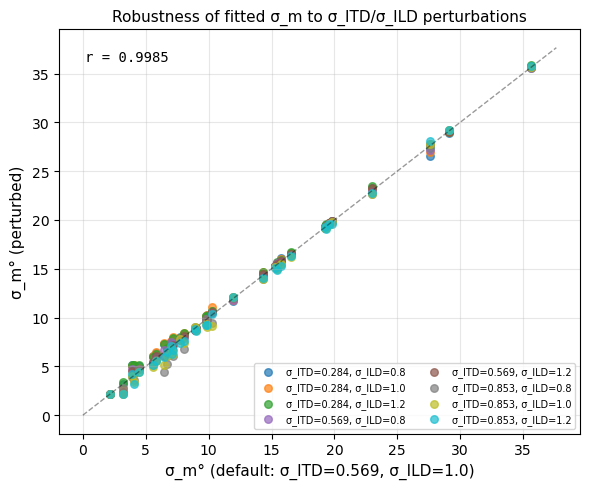

Max |Δσ_m|:  2.05°
Mean |Δσ_m|: 0.30°
Std |Δσ_m|: 0.32°
σ_m range (default): 2.2° – 35.6°


In [8]:
kappa_default = np.array([kappa_results[pid][default_idx] for pid in participants])
sigma_default = np.array([kappa_to_sigma(k) for k in kappa_default])

perturbed_indices = [i for i in range(len(conditions)) if i != default_idx]

all_sigma_perturbed = np.array([
    [kappa_to_sigma(kappa_results[pid][c_idx]) for pid in participants]
    for c_idx in perturbed_indices
])  # (n_perturbed, n_participants)

fig, ax = plt.subplots(figsize=(6, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(perturbed_indices)))
for j, c_idx in enumerate(perturbed_indices):
    sit, sil = conditions[c_idx]
    sigma_perturbed = all_sigma_perturbed[j]
    ax.scatter(sigma_default, sigma_perturbed, s=30, alpha=0.7, color=colors[j],
               label=f'σ_ITD={sit:.3f}, σ_ILD={sil:.1f}')

lim = max(sigma_default.max(), all_sigma_perturbed.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, lw=1)
ax.set_xlabel('σ_m° (default: σ_ITD=0.569, σ_ILD=1.0)', fontsize=11)
ax.set_ylabel('σ_m° (perturbed)', fontsize=11)
ax.set_title('Robustness of fitted σ_m to σ_ITD/σ_ILD perturbations', fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

r_all, _ = pearsonr(np.tile(sigma_default, len(perturbed_indices)),
                     all_sigma_perturbed.flatten())
ax.text(0.05, 0.95, f'r = {r_all:.4f}', transform=ax.transAxes,
        fontsize=10, va='top', fontfamily='monospace')

plt.tight_layout()
paths.FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(paths.FIG_DIR / 'fig_kappa_sensitivity.pdf', bbox_inches='tight')
plt.show()

sigma_shifts = all_sigma_perturbed - sigma_default[None, :]
print(f'Max |Δσ_m|:  {np.abs(sigma_shifts).max():.2f}°')
print(f'Mean |Δσ_m|: {np.abs(sigma_shifts).mean():.2f}°')
print(f'Std |Δσ_m|: {np.abs(sigma_shifts).std():.2f}°')

print(f'σ_m range (default): {sigma_default.min():.1f}° – {sigma_default.max():.1f}°')

## Panel B: rmsL contribution from σ_ITD/σ_ILD variation alone (κ_m = ∞)

Run the ITD+ILD-only model with no motor noise (take mean of argmax predictions, no
von Mises draw) across the same σ grid. The spread of rmsL across the grid should be
negligible compared to the observed inter-individual range, showing that σ_ITD/σ_ILD
variation cannot explain the observed differences in lateral accuracy.

In [5]:
N_MC = 100
np.random.seed(42)

rmsL_no_motor = {pid: {} for pid in participants}
rmsL_real = {}

for pid in participants:
    subj_data = obs_tbl[obs_tbl['participant'] == pid]
    sofa_path = str(paths.participant_sofa(pid))

    model = BayesianListener(sofa_path)
    model.compute_template(interpolation='SHMAX', cache_dir=paths.CACHE_DIR)

    template_itd = model.template.itd.flatten()
    template_ild = model.template.ild.flatten()
    template_lat = model.template.coords.lateral

    target_indices = model.coords.find_nearest(targets_coords)[0][0]
    target_itd = model.target.itd[target_indices].flatten()
    target_ild = model.target.ild[target_indices].flatten()

    resp_coords = pf.Coordinates.from_spherical_elevation(
        np.deg2rad(subj_data['azi_response'].values),
        np.deg2rad(subj_data['ele_response'].values),
        np.ones(len(subj_data)))
    resp_lat = resp_coords.lateral

    targ_coords = pf.Coordinates.from_spherical_elevation(
        np.deg2rad(subj_data['azi_target'].values),
        np.deg2rad(subj_data['ele_target'].values),
        np.ones(len(subj_data)))
    targ_lat = targ_coords.lateral
    trial_target_indices = targets_coords.find_nearest(targ_coords)[0][0]

    rmsL_real[pid] = np.rad2deg(rmsL(targ_lat, resp_lat))

    n_trials = len(subj_data)

    for c_idx, (sigma_itd, sigma_ild) in enumerate(conditions):
        est_lat_mean = np.zeros(n_trials)

        for i, t_idx in enumerate(trial_target_indices):
            noisy_itd = target_itd[t_idx] + np.random.normal(0, sigma_itd, N_MC)
            noisy_ild = target_ild[t_idx] + np.random.normal(0, sigma_ild, N_MC)

            itd_diff = (template_itd[None, :] - noisy_itd[:, None]) / sigma_itd
            ild_diff = (template_ild[None, :] - noisy_ild[:, None]) / sigma_ild
            loglik = -0.5 * (itd_diff**2 + ild_diff**2)

            best_indices = np.argmax(loglik, axis=1)
            est_lat_mean[i] = np.mean(template_lat[best_indices])

        rmsL_no_motor[pid][c_idx] = np.rad2deg(rmsL(targ_lat, est_lat_mean))

    print(f'{pid}: rmsL_real={rmsL_real[pid]:.1f}°  rmsL_no_motor(default)={rmsL_no_motor[pid][default_idx]:.1f}°')

print('Done.')

✓ Loading from cache: P0001_FreeFieldCompMinPhase_48kHz_5b84d57d_SHMAX_20260513_155734.pkl
✓ Cache loaded successfully
P0001: rmsL_real=9.5°  rmsL_no_motor(default)=5.6°
✓ Loading from cache: P0006_FreeFieldCompMinPhase_48kHz_563e4dd7_SHMAX_20260513_155938.pkl
✓ Cache loaded successfully
P0006: rmsL_real=5.7°  rmsL_no_motor(default)=1.6°
✓ Loading from cache: P0019_FreeFieldCompMinPhase_48kHz_3b5312cd_SHMAX_20260513_155948.pkl
✓ Cache loaded successfully
P0019: rmsL_real=8.2°  rmsL_no_motor(default)=2.9°
✓ Loading from cache: P0031_FreeFieldCompMinPhase_48kHz_b7a76c42_SHMAX_20260513_155956.pkl
✓ Cache loaded successfully
P0031: rmsL_real=6.7°  rmsL_no_motor(default)=2.1°
✓ Loading from cache: P0043_FreeFieldCompMinPhase_48kHz_bc7bca3c_SHMAX_20260513_160006.pkl
✓ Cache loaded successfully
P0043: rmsL_real=7.4°  rmsL_no_motor(default)=3.6°
✓ Loading from cache: P0124_FreeFieldCompMinPhase_48kHz_e064aad6_SHMAX_20260513_160015.pkl
✓ Cache loaded successfully
P0124: rmsL_real=9.2°  rmsL_no_

## Panel B plot

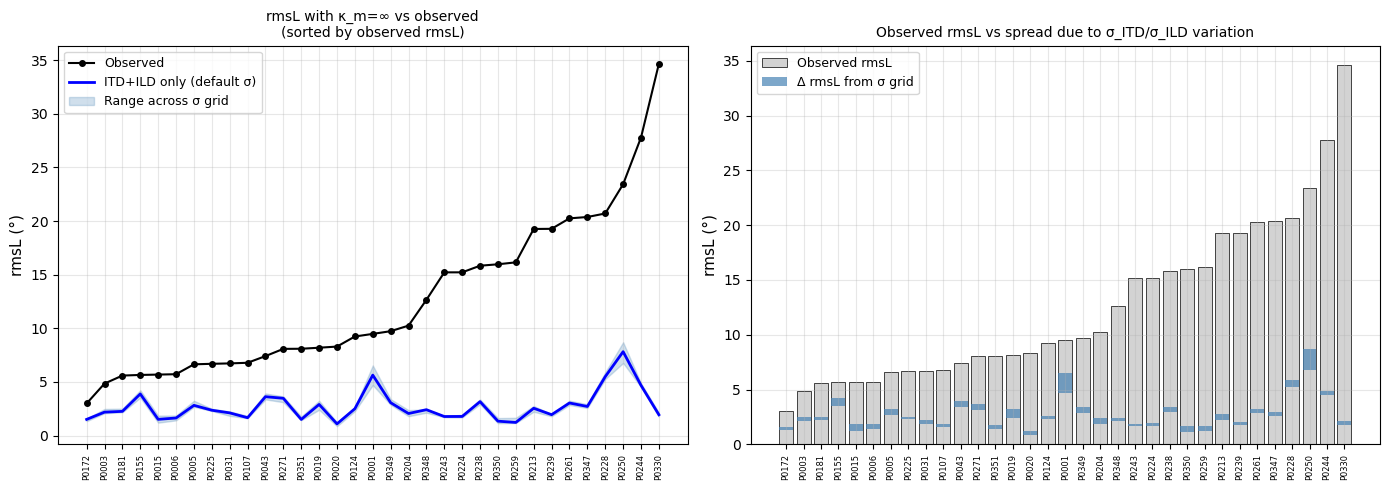

Observed rmsL range:                   3.0° – 34.7°
rmsL no-motor (default), mean±std:     2.7° ± 1.4°
Max envelope width from σ variation:   1.94°
Mean envelope width from σ variation:  0.51°


In [ ]:
rmsL_real_arr = np.array([rmsL_real[pid] for pid in participants])

# shape (n_conditions, n_participants)
rmsL_nm_matrix = np.array([
    [rmsL_no_motor[pid][c_idx] for pid in participants]
    for c_idx in range(len(conditions))
])

sort_idx = np.argsort(rmsL_real_arr)
pids_sorted = [participants[i] for i in sort_idx]
x = np.arange(len(participants))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: per-participant rmsL (no motor) envelope vs observed ---
ax = axes[0]
ax.plot(x, rmsL_real_arr[sort_idx], 'ko-', ms=4, lw=1.5, label='Observed')
ax.plot(x, rmsL_nm_matrix[default_idx, sort_idx], 'b-', lw=2,
        label='ITD+ILD only (default σ)')
ax.fill_between(x,
                rmsL_nm_matrix[:, sort_idx].min(axis=0),
                rmsL_nm_matrix[:, sort_idx].max(axis=0),
                color='steelblue', alpha=0.25, label='Range across σ grid')
ax.set_xticks(x)
ax.set_xticklabels(pids_sorted, rotation=90, fontsize=6)
ax.set_ylabel('rmsL (°)', fontsize=11)
ax.set_title('rmsL with κ_m=∞ vs observed\n(sorted by observed rmsL)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right: envelope width vs observed inter-individual range ---
ax = axes[1]
envelope_width = rmsL_nm_matrix.max(axis=0) - rmsL_nm_matrix.min(axis=0)

ax.bar(x, rmsL_real_arr[sort_idx], color='lightgray', edgecolor='k', lw=0.5,
       label='Observed rmsL')
ax.bar(x, envelope_width[sort_idx],
       bottom=rmsL_nm_matrix.min(axis=0)[sort_idx],
       color='steelblue', alpha=0.7, label='Δ rmsL from σ grid')
ax.set_xticks(x)
ax.set_xticklabels(pids_sorted, rotation=90, fontsize=6)
ax.set_ylabel('rmsL (°)', fontsize=11)
ax.set_title('Observed rmsL vs spread due to σ_ITD/σ_ILD variation', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Observed rmsL range:                   {rmsL_real_arr.min():.1f}° – {rmsL_real_arr.max():.1f}°')
print(f'rmsL no-motor (default), mean±std:     {rmsL_nm_matrix[default_idx].mean():.1f}° ± {rmsL_nm_matrix[default_idx].std():.1f}°')
print(f'Max envelope width from σ variation:   {envelope_width.max():.2f}°')
print(f'Mean envelope width from σ variation:  {envelope_width.mean():.2f}°')

## Summary table: per-condition κ_m robustness

In [7]:
rows = []
for c_idx, (sit, sil) in enumerate(conditions):
    sigmas = np.array([kappa_to_sigma(kappa_results[pid][c_idx]) for pid in participants])
    delta = sigmas - sigma_default
    r, _ = pearsonr(sigma_default, sigmas)
    rows.append({
        'σ_ITD': f'{sit:.3f}',
        'σ_ILD': f'{sil:.1f}',
        'default': '*' if c_idx == default_idx else '',
        'r(σ_m vs default)': f'{r:.4f}',
        'mean |Δσ_m| (°)': f'{np.abs(delta).mean():.2f}',
        'max |Δσ_m| (°)': f'{np.abs(delta).max():.2f}',
    })

print(pd.DataFrame(rows).to_string(index=False))

σ_ITD σ_ILD default r(σ_m vs default) mean |Δσ_m| (°) max |Δσ_m| (°)
0.284   0.8                    0.9991            0.34           1.19
0.284   1.0                    0.9990            0.35           1.12
0.284   1.2                    0.9994            0.32           1.23
0.569   0.8                    0.9993            0.18           0.98
0.569   1.0       *            1.0000            0.00           0.00
0.569   1.2                    0.9995            0.17           0.81
0.853   0.8                    0.9983            0.35           2.05
0.853   1.0                    0.9991            0.38           1.31
0.853   1.2                    0.9993            0.34           1.03
